## Double Decent: Revising the bias variance classic graph

- Least squares Regression
- Singulaer Wert Zerlegung
- Minimum-Norm-Lösung (Überparametrisierung) 
- Ridgid Regression mit lambda
/ https://www.youtube.com/watch?v=z64a7USuGX0
- Double Descent Demystified: Identifying, Interpreting & Ablating the Sources of a Deep Learning Puzzle https://arxiv.org/pdf/2303.14151  



# Klassische Least Squares und SVD – Einführung in Polynom-Fitting

## 1. Problemstellung
Gegeben $N$ Beobachtungen $(x_i, y_i)$.  
Wir wollen ein Polynom Grad $p$ fitten:

$$
y_i \approx \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \dots + \beta_p x_i^p
$$

Matrixschreibweise:

$$
X =
\begin{bmatrix}
1 & x_1 & x_1^2 & \dots & x_1^p \\
1 & x_2 & x_2^2 & \dots & x_2^p \\
\vdots & \vdots & \vdots & & \vdots \\
1 & x_N & x_N^2 & \dots & x_N^p
\end{bmatrix}, \quad
y =
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_N
\end{bmatrix}
$$

Ziel:
$$
\min_\beta \|y - X\beta\|_2^2
$$

Lösung (Normalengleichungen):
$$
\hat\beta = (X^T X)^{-1} X^T y
$$
Nur gültig, wenn $X^T X$ invertierbar ist ($\text{rank}(X)=p+1 \le N$).

---

## 2. Geometrische Interpretation
- $X\beta$ ist Projektion von $y$ in den Spaltenraum von $X$.  
- Residuum $r = y - X\hat\beta$ steht senkrecht auf diesem Raum:
  $$
  X^T r = 0
  $$
Das ist die Bedingung der Normalengleichungen.

---

## 3. Singulärwertzerlegung (SVD)
Jede Matrix $X \in \mathbb{R}^{N \times D}$ lässt sich schreiben als:

$$
X = U \Sigma V^T
$$

mit  
- $U$: orthogonale Matrix $N\times N$  
- $V$: orthogonale Matrix $D\times D$  
- $\Sigma$: Diagonal­matrix mit Singulärwerten $\sigma_1 \ge \sigma_2 \ge ... \ge \sigma_R > 0$, $R = \text{rank}(X)$

Einsetzen in Least-Squares-Lösung:

$$
\hat\beta = V \Sigma^{-1} U^T y
$$

Kleine $\sigma_i$ führen zu großen $\frac{1}{\sigma_i}$ und damit zu numerischer Instabilität und Varianzverstärkung.

---

## 4. Überparameterisierte Fälle und Minimum-Norm-Lösung
Wenn $D > N$ (mehr Parameter als Daten), gibt es unendlich viele Lösungen mit $X\beta = y$.

Die **Minimum-Norm-Lösung** minimiert die Koeffizientenlänge:
$$
\hat\beta_{\text{min-norm}} = \arg\min_\beta \{\|\beta\|_2 : X\beta = y\}
$$

Sie ergibt sich über die **Moore–Penrose-Pseudoinverse**:
$$
\hat\beta = X^+ y = V \Sigma^+ U^T y
$$

mit
$$
\Sigma^+ =
\begin{cases}
\text{diag}(1/\sigma_i) & \text{für } i\le R \\
0 & \text{sonst}
\end{cases}
$$

Diese Lösung wählt unter allen exakten Fits den mit minimaler $L_2$-Norm.

---

## 5. Verbindung zu Double Descent
- Wenn $D \approx N$: einige $\sigma_i \approx 0$ → hohe Varianz → Fehlerpeak.  
- Wenn $D \gg N$: Minimum-Norm-Lösung dämpft ungenutzte Richtungen → Varianz sinkt → zweiter Abstieg.

---

## 6. Nächster Schritt
SVD-Herleitung der Lösung aus den Normalengleichungen:
$$
X^T X \beta = X^T y \Rightarrow \hat\beta = V \Sigma^{-1} U^T y
$$

Damit wird der Zusammenhang zwischen Least Squares und Minimum-Norm präzise sichtbar.


Geschätzte Koeffizienten β̂ = [ 1.095   2.0618 -1.6005]


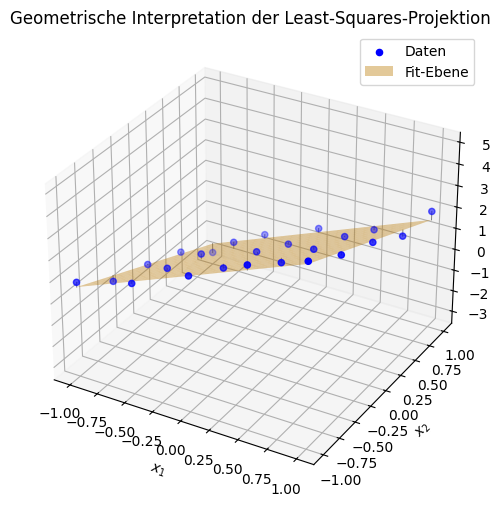

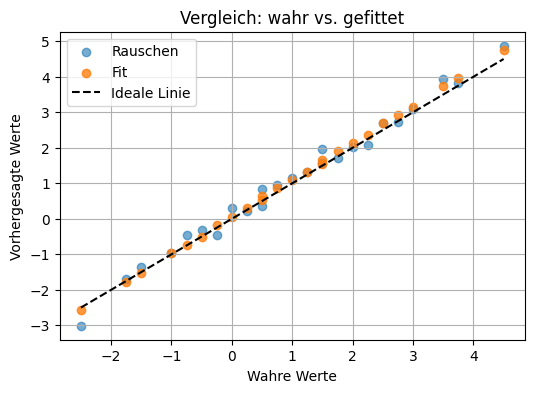

In [337]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)

# 1) Daten erzeugen
N = 5
x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
x1, x2 = np.meshgrid(x1, x2)
x1, x2 = x1.ravel(), x2.ravel()

# Wahres Modell: y = 1 + 2x1 - 1.5x2 + noise
y_true = 1 + 2*x1 - 1.5*x2
y = y_true + 0.2*np.random.randn(len(x1))

# 2) Design-Matrix (1, x1, x2)
X = np.column_stack([np.ones_like(x1), x1, x2])

# 3) Least-Squares-Schätzung
beta_hat = np.linalg.pinv(X) @ y
y_hat = X @ beta_hat

print("Geschätzte Koeffizienten β̂ =", beta_hat.round(4))

# 4) 3D-Plot: Daten, Fit und Residuen
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Originaldaten
ax.scatter(x1, x2, y, label='Daten', color='blue', s=20)

# Gefittete Ebene
xg, yg = np.meshgrid(np.linspace(-1,1,30), np.linspace(-1,1,30))
zg = beta_hat[0] + beta_hat[1]*xg + beta_hat[2]*yg
ax.plot_surface(xg, yg, zg, alpha=0.4, color='orange', label='Fit-Ebene')

# Residuen (graue Linien)
for xi, yi, zi, zhi in zip(x1, x2, y, y_hat):
    ax.plot([xi, xi], [yi, yi], [zi, zhi], color='gray', linewidth=0.7)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$y$')
ax.set_title('Geometrische Interpretation der Least-Squares-Projektion')
plt.legend()
plt.show()

# 5) Vergleich: wahre vs. gefittete Werte
plt.figure(figsize=(6,4))
plt.scatter(y_true, y, label="Rauschen", alpha=0.6)
plt.scatter(y_true, y_hat, label="Fit", alpha=0.8)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', label="Ideale Linie")
plt.xlabel("Wahre Werte")
plt.ylabel("Vorhergesagte Werte")
plt.legend()
plt.title("Vergleich: wahr vs. gefittet")
plt.grid(True)
plt.show()


# Geometrische Interpretation der Least-Squares-Lösung (2D-Polynom)

## 1. Das Regressionsproblem in 2D

Wir betrachten das Modell

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \varepsilon
$$

mit Rauschterm $\varepsilon \sim \mathcal{N}(0, \sigma^2)$.

In Matrixform:

$$
X =
\begin{bmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
\vdots & \vdots & \vdots \\
1 & x_{N1} & x_{N2}
\end{bmatrix}, \quad
y =
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_N
\end{bmatrix}
$$

Gesucht ist die Schätzung

$$
\hat\beta = \arg\min_\beta \|y - X\beta\|_2^2
$$

Die Normalengleichungen lauten:

$$
X^T X \hat\beta = X^T y
$$

und die Lösung (falls $X^T X$ invertierbar ist):

$$
\hat\beta = (X^T X)^{-1} X^T y
$$

---

## 2. Geometrische Interpretation

### 2.1. Spaltenraum von $X$

Die Spalten von $X$ bilden drei Vektoren in $\mathbb{R}^N$:
- $X_1$: konstante 1-Spalte (Offset)
- $X_2$: Werte von $x_1$
- $X_3$: Werte von $x_2$

Alle möglichen Linearkombinationen dieser Spalten bilden den **Spaltenraum von $X$**.  
Jeder Vektor $X\beta$ liegt in dieser 3D-Teilmenge des $\mathbb{R}^N$.

---

### 2.2. Projektion

Die **Least-Squares-Lösung** ist die orthogonale Projektion von $y$ auf den Spaltenraum:

$$
X^T (y - X\hat\beta) = 0
$$

Das bedeutet:

- Das Residuum $r = y - X\hat\beta$ steht **senkrecht** auf allen Spalten von $X$.
- Der Fit $X\hat\beta$ ist der Punkt im Spaltenraum, der $y$ am nächsten liegt.
- Der Unterschied $r$ ist die orthogonale Distanz zur Modellfläche.

---

### 2.3. In der 3D-Visualisierung

Für das Beispiel $y = 1 + 2x_1 - 1.5x_2 + \varepsilon$ gilt:

- Der Spaltenraum entspricht einer **Ebene im Raum $(x_1, x_2, y)$**.
- Der Fit $X\hat\beta$ ist eine **Ebene**, die den Datenpunkten am nächsten liegt.
- Jeder Datenpunkt $(x_{i1}, x_{i2}, y_i)$ wird orthogonal auf diese Ebene projiziert.
- Die **grauen Linien** zeigen die orthogonalen Residuen.

---

### 2.4. Mathematische Darstellung der Projektion

Die Projektion kann als Matrix geschrieben werden:

$$
P = X (X^T X)^{-1} X^T
$$

Dabei ist $P$ der **Projektor auf den Spaltenraum von $X$**, mit den Eigenschaften:

$$
P^2 = P, \quad P = P^T
$$

Dann gilt:

$$
\hat{y} = P y, \quad r = (I - P) y, \quad X^T r = 0
$$

→ Das Residuum ist orthogonal zum Spaltenraum.

---

## 4. Ergebnis und Interpretation

- Die orange Fläche ist die gefittete Ebene $ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 $.

- Die blauen Punkte sind die beobachteten Daten.

- Die grauen Linien sind die orthogonalen Residuen.

- Das zweite Diagramm zeigt, dass die vorhergesagten Werte $\hat{y}$ gut entlang der idealen Linie $y_{\text{true}} = y_{\text{hat}}$ liegen.

# SVD-Herleitung der Normalengleichungen und Minimum-Norm-Lösung

## 1. Ausgangspunkt

Wir wollen die Lösung des kleinsten-Quadrate-Problems

$$
\min_\beta \|y - X\beta\|_2^2
$$

verstehen, insbesondere wenn \(X\) **nicht vollen Rang** hat (z. B. bei Überparametrisierung, \(p > n\)).  
Dann ist \(X^T X\) **nicht invertierbar** und es existieren **unendlich viele Lösungen**.

Wir suchen daher **die Lösung mit minimaler Norm**:

$$
\hat{\beta}_{\text{min-norm}} = \arg\min_\beta \| \beta \|_2
\quad \text{unter der Nebenbedingung } \quad X\beta = X\hat{\beta}_{LS}
$$

---

## 2. Singulärwertzerlegung (SVD) – Begriffserklärungen

Jede Matrix \(X \in \mathbb{R}^{n \times p}\) lässt sich faktorisieren als

$$
X = U \Sigma V^T
$$

mit:

- \(U \in \mathbb{R}^{n \times n}\) orthogonal: \(U^T U = I_n\)  
- \(V \in \mathbb{R}^{p \times p}\) orthogonal: \(V^T V = I_p\)  
- \(\Sigma \in \mathbb{R}^{n \times p}\) diagonal mit Singulärwerten

$$
\Sigma =
\begin{bmatrix}
\sigma_1 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_r \\
0 & 0 & \cdots & 0
\end{bmatrix}, 
\quad \sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r > 0
$$

mit **Rang** \(r = \mathrm{rank}(X)\).

---

### Erklärung der Begriffe

#### 1. Rang der Matrix \(r = \mathrm{rank}(X)\)
- Der Rang ist die maximale Anzahl **linear unabhängiger Spalten** (oder Zeilen) von \(X\).  
- **Linear unabhängig** bedeutet: Keine Spalte (bzw. Zeile) kann als Linearkombination der anderen dargestellt werden.  
- Praktisch: Wenn eine Spalte wie \([1,2,3]^T\) existiert und eine zweite \([2,4,6]^T\), ist die zweite linear abhängig → Rang = 1 statt 2.  
- **Berechnung des Rangs:**
  1. **Gauss-Elimination / Zeilenstufenform**: Zähle die Anzahl der nicht-null Zeilen nach Reduktion auf obere Dreiecksform.  
  2. **SVD-basierte Methode**: Rang = Anzahl der Singulärwerte \(\sigma_i > 0\).  
  3. **Numerisch** (z. B. Python/Numpy): `np.linalg.matrix_rank(X)` verwendet eine Schwelle, um kleine Rundungswerte zu ignorieren.  

#### 2. Orthogonale Matrizen \(U\) und \(V\)
- **Orthogonal** bedeutet: Die Spalten bilden eine **orthonormale Basis**, d.h.:
  1. **Orthogonal**: Jede Spalte steht senkrecht auf allen anderen (\(u_i^T u_j = 0\) für \(i \neq j\))  
  2. **Normiert**: Jede Spalte hat Länge 1 (\(\|u_i\|_2 = 1\))  
- Vorteil: Transformationen durch orthogonale Matrizen verändern **nicht die Länge** von Vektoren.

#### 3. Einheitsmatrix \(I_n\) bzw. \(I_p\)
- \(I_n\) ist die \(n \times n\) Einheitsmatrix:

$$
I_n =
\begin{bmatrix}
1 & 0 & \cdots & 0\\
0 & 1 & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & 1
\end{bmatrix}
$$

- Analog ist \(I_p\) die \(p \times p\) Einheitsmatrix.  
- In \(U^T U = I_n\) bedeutet das: Die Spalten von \(U\) sind **orthonormal**.

#### 4. Diagonalmatrix \(\Sigma\) und Singulärwerte \(\sigma_i\)
- \(\Sigma\) ist diagonal: nur Hauptdiagonale ungleich null.  
- \(\sigma_1 \ge \sigma_2 \ge \dots \ge \sigma_r > 0\)  
  - Die \(\sigma_i\) heißen **Singulärwerte** von \(X\)  
  - Sie messen die “Stärke” jeder unabhängigen Richtung im Spaltenraum von \(X\)  
  - Null-Singularwerte (\(i > r\)) entsprechen Richtungen im **Nullraum**, die \(X\beta = 0\) erzeugen.

---

## 3. Projektion in den SVD-Koordinaten

Wir schreiben das Least-Squares-Problem um:

$$
\min_\beta \|y - X\beta\|_2^2
= \min_\beta \|y - U \Sigma V^T \beta\|_2^2
$$

Da \(U\) orthogonal ist, gilt:

$$
\|y - U\Sigma V^T \beta\|_2 = \|U^T y - \Sigma V^T \beta\|_2
$$

Wir definieren:

$$
y' = U^T y, \quad \beta' = V^T \beta
$$

Dann wird das Problem zu:

$$
\min_{\beta'} \|y' - \Sigma \beta'\|_2^2
$$

---

## 4. Komponentenweise Lösung

Für \(i = 1, \dots, r\):

$$
\beta'_i = \frac{y'_i}{\sigma_i}
$$

Für \(i > r\) (Null-Singularwerte):

$$
\beta'_i = 0
$$

→ dies minimiert die Norm \(\|\beta\|_2\) und erzeugt die **Minimum-Norm-Lösung**.

---

## 5. Rücktransformation

$$
\hat{\beta}_{\text{min-norm}} = V \beta' = V \Sigma^+ U^T y
$$

mit der **Moore-Penrose-Pseudoinversen**:

$$
\Sigma^+ =
\begin{bmatrix}
1/\sigma_1 & 0 & \cdots & 0 \\
0 & 1/\sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & 1/\sigma_r \\
0 & 0 & \cdots & 0
\end{bmatrix}^T
$$

---

## 6. Projektion auf den Spaltenraum von \(X\)

$$
\hat{y} = X \hat{\beta} = U \Sigma V^T (V \Sigma^+ U^T y) = U \Sigma \Sigma^+ U^T y
$$

Da \(\Sigma \Sigma^+\) die Einheitsmatrix im Rang-\(r\)-Unterraum ist:

$$
\Sigma \Sigma^+ =
\begin{bmatrix}
I_r & 0 \\
0 & 0
\end{bmatrix}, \quad
\hat{y} = U_r U_r^T y
$$

- \(U_r\) enthält die ersten \(r\) Spalten von \(U\) (Basis des Spaltenraums von \(X\))  
- \(U_r U_r^T\) ist der **Projektor auf diesen Raum**  
- Geometrisch: \(y\) wird orthogonal auf \(\text{span}(X)\) projiziert, Residuum \(r = y - \hat{y}\) liegt orthogonal dazu.

---

## 7. Eindeutigkeit der Minimum-Norm-Lösung

- Wenn \(p > n\), gibt es unendlich viele \(\beta\) mit \(X\beta = \hat{y}\).  
- Diese unterscheiden sich um einen beliebigen Vektor \(z\) im **Nullraum von \(X\)**: \(X z = 0\).  
- Wahl \(z = 0\) minimiert \(\|\beta\|_2\).  
- SVD garantiert dies durch Setzen von \(\beta'_i = 0\) für \(\sigma_i = 0\).

---

## 8. Zusammenfassung

| Schritt | Ausdruck | Bedeutung |
|----------|-----------|-----------|
| 1 | \(X = U \Sigma V^T\) | SVD von \(X\) |
| 2 | \(\hat{\beta} = V \Sigma^+ U^T y\) | Pseudoinverse-Lösung |
| 3 | \(\hat{y} = U_r U_r^T y\) | Projektion auf Spaltenraum |
| 4 | \(\hat{\beta}_{\text{min-norm}} = \arg\min_{\beta: X\beta = \hat{y}} \|\beta\|_2\) | Minimum-Norm-Eigenschaft |

---

## 9. Python-Check (optional)

```python
import numpy as np

# SVD-Demonstration
U, S, VT = np.linalg.svd(X, full_matrices=False)

# Moore-Penrose-Pseudoinverse über SVD
Sigma_plus = np.diag(1/S)
X_pinv = VT.T @ Sigma_plus @ U.T

beta_svd = X_pinv @ y

print("SVD-basierte β̂ =", beta_svd.round(4))
print("Direkt mit np.linalg.pinv:", np.linalg.pinv(X) @ y)


## SVD from Scratch
1. Beispieldaten und Designmatrix 


Gegeben $N=3$ Beobachtungen $(x_i, y_i)$.  
Wir wollen ein Polynom Grad $p=3$ fitten:

$$
y_i \approx \beta_0 + \beta_1 x_i + \beta_2 x_i^2
$$

Wir haben eine Designmatrix 3x3 mit x1, x2, x3


In [338]:
import numpy as np

x = np.array([-1.0, 0.0, 1.0])
y = np.array([2.0, 0.5, 2.0])

# Designmatrix X (3x3)
X = np.column_stack([np.ones_like(x), x, x**2])
print("X =\n", X)

X =
 [[ 1. -1.  1.]
 [ 1.  0.  0.]
 [ 1.  1.  1.]]


Jede Matrix $$ (X \in \mathbb{R}^{n \times p}) $$ lässt sich faktorisieren als

$$
X = U \Sigma V^T
$$

mit:
$$
- (U \in \mathbb{R}^{n \times n}) orthogonal: (U^T U = I_n)  
$$
$$
- (V \in \mathbb{R}^{p \times p}) orthogonal: (V^T V = I_p)  
$$
$$
- (\Sigma \in \mathbb{R}^{n \times p})  diagonal mit Singulärwerten //

$$


Hier sind die Schritte:

1. $ X^T X $ Eigenzerlegen in Eigenvektoren $\lambda_i$ und Eigenvektoren $v_i$
2. Singulärwerte $\sigma_i = \sqrt(max(\lambda_i,0))$ bestimmen 
3. $ V $ Matrix bestimmen $[v1,... vp]$
4. Ur die rechte Halbmatrix von U bestimmen $Ur = XVr diag(1/\sigma_i)$ für $\sigma_i > 0$
5. $\Sigma$ als diagonalmatrix nxp aufbauen mit $\sigma_i$
6. Pruefen X = U \Sigma V^T


In [339]:
X # Designmatrix mit Spalten für x^0, x^1, x^2

# Eigenwerte und Eigenvektoren der Matrix X^T X berechnen
# 1) symmetrische Eigenzerlegung von X^T X (use eigh)
XtX = X.T @ X
eigenvalues, eigenvectors = np.linalg.eigh(XtX)   # liefert reale, orthonormale Eigenvektoren

print("Eigenwerte =", eigenvalues)
print("Eigenvektoren =\n", eigenvectors)

#1.1 Eigenwerte auf negative Werte prüfen
if np.any(eigenvalues < 0):
    print("Warnung: Negative Eigenwerte gefunden!")
else:
    print("Alle Eigenwerte sind nicht-negativ.")
    
# negative Eigenwerte auf 0 setzen
eigenvalues = np.maximum(eigenvalues, 0)

# absteigend sortieren der Eigenwerte und entsprechende Eigenvektoren mathematisch nicht notwendig, aber oft üblich
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
V = eigenvectors[:, idx]       # Spalten sind v_i

# 2. Singulärwerte bestimmen 
sigma_vec = np.sqrt(eigenvalues)

print("Singulärwerte =", sigma_vec)

# 3. V Matrix aus Eigenvektoren zusammensetzen
print("V =\n", V)

# 4. Ur Matrix berechnen
Ur = X @ V @ np.diag(1/sigma_vec)
print("Ur =\n", Ur)
U = Ur

# Prüfen der Orthonormalität von Ur 
print("Orthonormalitätsprüfung (Ur^T * Ur = I):\n", Ur.T @ Ur)

if np.allclose(Ur.T @ Ur, np.eye(Ur.shape[1])):
    print("Ur ist orthonormal.")
else:
    print("Ur ist nicht orthonormal.")
    
# Wenn Ur nicht orthonormal ist QR-Zerlegung durchführen und Ur orthonormal ergänzen
if not np.allclose(Ur.T @ Ur, np.eye(Ur.shape[1])):
    Q, R = np.linalg.qr(Ur)
    Ur = Q
    print("Ur wurde durch QR-Zerlegung orthonormalisiert.")
    print("Orthonormalitätsprüfung (Ur^T * Ur = I):\n", Ur.T @ Ur)

# 6. Sigma Matrix erstellen
Sigma = np.zeros((X.shape[0], X.shape[1]))
np.fill_diagonal(Sigma, sigma_vec)
print("Sigma =\n", Sigma)

# Pruefen ob X = Ur @ Sigma @ V^T
X_reconstructed = Ur @ Sigma @ V.T
print("Rekonstruierte X =\n", X_reconstructed)
# Prüfen ob die Rekonstruktion von X nahe am Original liegt
if np.allclose(X, X_reconstructed):
    print("Rekonstruktion erfolgreich: X ist nahe an der rekonstruierten X.")
else:
    print("Rekonstruktion fehlgeschlagen: X unterscheidet sich von der rekonstruierten X.")
    



Eigenwerte = [0.43844719 2.         4.56155281]
Eigenvektoren =
 [[-0.61541221  0.         -0.78820544]
 [ 0.         -1.          0.        ]
 [ 0.78820544  0.         -0.61541221]]
Alle Eigenwerte sind nicht-negativ.
Singulärwerte = [2.13577921 1.41421356 0.66215345]
V =
 [[-0.78820544  0.         -0.61541221]
 [ 0.         -1.          0.        ]
 [-0.61541221  0.          0.78820544]]
Ur =
 [[-0.6571923   0.70710678  0.26095647]
 [-0.36904818  0.         -0.92941026]
 [-0.6571923  -0.70710678  0.26095647]]
Orthonormalitätsprüfung (Ur^T * Ur = I):
 [[ 1.00000000e+00  2.70678324e-17 -2.60497826e-17]
 [ 2.70678324e-17  1.00000000e+00  9.01545752e-18]
 [-2.60497826e-17  9.01545752e-18  1.00000000e+00]]
Ur ist orthonormal.
Sigma =
 [[2.13577921 0.         0.        ]
 [0.         1.41421356 0.        ]
 [0.         0.         0.66215345]]
Rekonstruierte X =
 [[ 1.00000000e+00 -1.00000000e+00  1.00000000e+00]
 [ 1.00000000e+00  0.00000000e+00  2.09898045e-17]
 [ 1.00000000e+00  1.000000

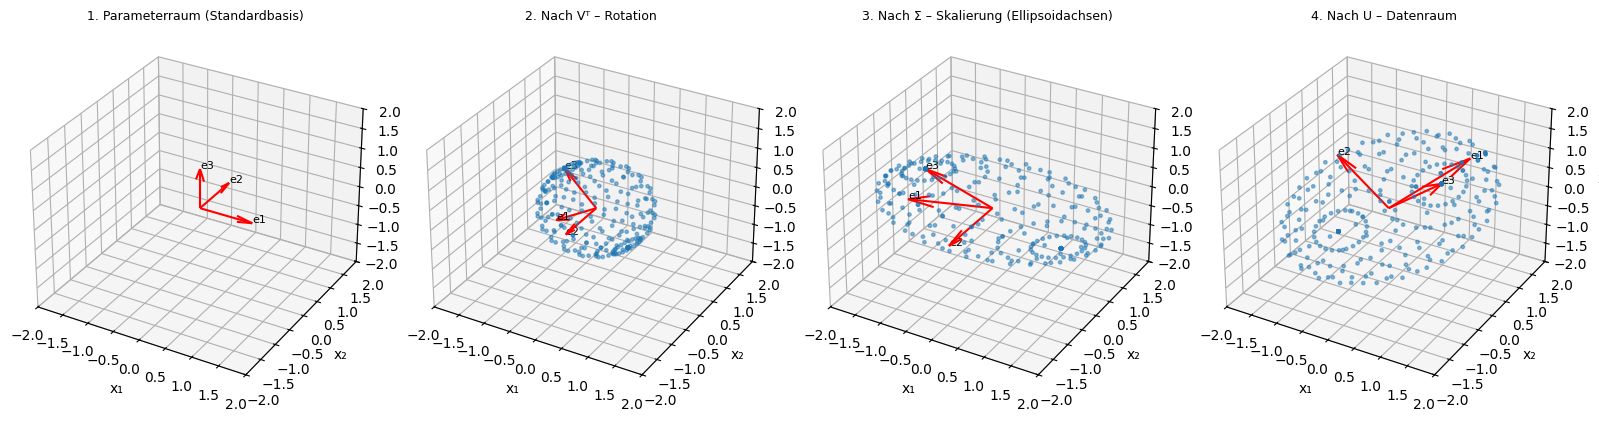

Singulärwerte σ = [2.135779 1.414214 0.662153]
Eigenwerte λ = [4.561553 2.       0.438447]

V (Richtungen im Parameterraum):
 [[-0.788205  0.       -0.615412]
 [ 0.       -1.        0.      ]
 [-0.615412  0.        0.788205]]

U (Richtungen im Datenraum):
 [[-0.657192  0.707107  0.260956]
 [-0.369048  0.       -0.92941 ]
 [-0.657192 -0.707107  0.260956]]


In [340]:
## Geometrische Interpretation von SVD  bzw. Visualisierung von U Sigma und V 

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Designmatrix (3 Messpunkte, quadratisches Polynom) ---


# --- SVD-Berechnung ---
#U, s, VT = np.linalg.svd(X, full_matrices=True)
#V = VT.T
#Sigma = np.zeros_like(X)
#np.fill_diagonal(Sigma, s)





# --- Einheitskugel im Parameterraum (zur Ellipsoid-Transformation) ---
phi = np.linspace(0, 2*np.pi, 24)
theta = np.linspace(0, np.pi, 12)
points = np.array([[np.sin(b)*np.cos(a), np.sin(b)*np.sin(a), np.cos(b)]
                   for a in phi for b in theta])

# --- Transformationen ---
param_basis = np.eye(3)
rot_basis = V.T @ param_basis
rot_points = (V.T @ points.T).T
scaled_basis = Sigma @ rot_basis
scaled_points = (Sigma @ (V.T @ points.T)).T
final_basis = U @ scaled_basis
final_points = (U @ (Sigma @ (V.T @ points.T))).T

# --- Plot: 4 Stufen ---
fig = plt.figure(figsize=(16,4))
titles = [
    "1. Parameterraum (Standardbasis)",
    "2. Nach Vᵀ – Rotation",
    "3. Nach Σ – Skalierung (Ellipsoidachsen)",
    "4. Nach U – Datenraum"
]

bases = [param_basis, rot_basis, scaled_basis, final_basis]
pointsets = [None, rot_points, scaled_points, final_points]

for i in range(4):
    ax = fig.add_subplot(1,4,i+1, projection='3d')
    A = bases[i]
    for j in range(3):
        v = A[:, j]
        ax.quiver(0,0,0, v[0], v[1], v[2], color='r', length=1.0)
        ax.text(v[0], v[1], v[2], f"e{j+1}", fontsize=8)
    if pointsets[i] is not None:
        P = pointsets[i]
        ax.scatter(P[:,0], P[:,1], P[:,2], s=6, alpha=0.5)
    ax.set_xlim([-2,2]); ax.set_ylim([-2,2]); ax.set_zlim([-2,2])
    ax.set_title(titles[i], fontsize=9)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂'); ax.set_zlabel('x₃')

plt.tight_layout()
plt.show()

# --- Vergleich numerisch ---
print("Singulärwerte σ =", np.round(sigma_vec,6))
print("Eigenwerte λ =", np.round(sigma_vec**2,6))
print("\nV (Richtungen im Parameterraum):\n", np.round(V,6))
print("\nU (Richtungen im Datenraum):\n", np.round(U,6))


# 🔹 SVD: Geometrische Visualisierung in Python

## Theorie & Bedeutung

### 1. SVD-Geometrie

Für eine Matrix

$$
X = U \Sigma V^T
$$

bestehen drei aufeinanderfolgende Transformationen:

| Schritt | Matrix   | Wirkung                                             | Geometrische Bedeutung                                          |
| ------- | -------- | --------------------------------------------------- | --------------------------------------------------------------- |
| 1       | $V^T$    | Rotation im **Parameterraum**                       | neue Koordinatenachsen (orthogonal)                             |
| 2       | $\Sigma$ | Skalierung der Achsen mit Singulärwerten ($\sigma_i$) | formt Kugel → Ellipsoid                                         |
| 3       | $U$      | Rotation in den **Datenraum**                       | orientiert Ellipsoid so, dass es die Spalten von $X$ beschreibt |

Damit gilt:

$$
X \beta = U \Sigma V^T \beta
$$

— $V^T$ rotiert, $\Sigma$ skaliert, $U$ rotiert erneut.

---

### 2. Eigenwerte und Eigenvektoren

Die SVD hängt eng mit der Eigenzerlegung von $X^T X$ zusammen:

$$
X^T X = V \Lambda V^T
$$

* **Eigenvektoren ($v_i$)** bilden die Spalten von $V$.  
  Sie sind orthogonale Richtungen im **Parameterraum**, entlang derer $X$ das Signal am stärksten streckt oder staucht.
* **Eigenwerte ($\lambda_i$)** sind die Quadrate der Singulärwerte:

$$
\lambda_i = \sigma_i^2
$$

* Große $\lambda_i$ → Richtung $v_i$ trägt stark zur Abbildung $X\beta$ bei.  
  Kleine oder null $\lambda_i$ → Richtungen im **Nullraum** (werden ausgelöscht).

---

### 3. Geometrische Interpretation

Eine Einheitskugel im Parameterraum wird durch $X$ zu einem Ellipsoid im Datenraum transformiert:

$$
\text{Einheitskugel} \xrightarrow{V^T} \text{rotierte Kugel} \xrightarrow{\Sigma} \text{Ellipsoid} \xrightarrow{U} \text{gedrehter Ellipsoid im Datenraum}
$$

Die Hauptachsen des Ellipsoids sind die Spalten von $U$, ihre Längen sind die Singulärwerte ($\sigma_i$).

---


## 🔹 Überparametrisierter Fall (p > n) – Nullraum & Minimum-Norm-Lösung

### 1. Setup

Wir betrachten eine Designmatrix mit mehr Parametern als Messpunkten:





In [341]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, FloatSlider, Dropdown

# --------------------------
# Beispielmatrix: p > n
# --------------------------
n, p = 3, 5
np.random.seed(0)
X = np.random.randn(n, p)
y = np.random.randn(n)

# Minimum-Norm-Lösung
X_pinv = np.linalg.pinv(X)
beta_min_norm = X_pinv @ y

# SVD
U, S, VT = np.linalg.svd(X)
rank = np.sum(S > 1e-10)
V = VT.T
Sigma = np.zeros((n, p))
np.fill_diagonal(Sigma, S)
null_space = VT[rank:].T  # (p, p-r)
num_null_vectors = null_space.shape[1]

# --------------------------
# Einheitskugel (3D → pD)
# --------------------------
phi = np.linspace(0, 2*np.pi, 40)
theta = np.linspace(0, np.pi, 20)
sphere_points_3d = np.array([[np.sin(t)*np.cos(p_), np.sin(t)*np.sin(p_), np.cos(t)] for p_ in phi for t in theta])
# Auf p Dimensionen erweitern (Rest mit Nullen auffüllen)
points = np.zeros((sphere_points_3d.shape[0], p))
points[:, :3] = sphere_points_3d

# --------------------------
# Interaktive Plot-Funktion
# --------------------------
def plot_svd_nullspace(view='Parameterraum', **coeffs):
    coeffs_array = np.array([coeffs.get(f'c{i+1}', 0) for i in range(num_null_vectors)])
    beta = beta_min_norm + null_space @ coeffs_array if num_null_vectors > 0 else beta_min_norm.copy()

    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    
    # --- Einheitskugel und Ellipsoid ---
    if view == 'Parameterraum':
        ellipsoid = (V.T @ points.T).T[:, :3]
    elif view == 'Sigma':
        ellipsoid = (Sigma @ (V.T @ points.T)).T[:, :3]
    elif view == 'Datenraum':
        ellipsoid = (U @ (Sigma @ (V.T @ points.T))).T[:, :3]
    else:
        ellipsoid = points[:, :3]
    
    ax.scatter(ellipsoid[:,0], ellipsoid[:,1], ellipsoid[:,2], s=6, alpha=0.3, color='gray')

    # --- Nullraumrichtungen (nur Parameterraum) ---
    if view == 'Parameterraum' and num_null_vectors > 0:
        origin = beta_min_norm[:3]
        for i in range(num_null_vectors):
            d = null_space[:3, i]
            ax.quiver(*origin, *d, length=1.0, color='green', arrow_length_ratio=0.1, linewidth=2)

    # --- Lösungen ---
    if view == 'Parameterraum':
        ax.scatter(*beta_min_norm[:3], color='red', s=100, label='Minimum-Norm')
        ax.scatter(*beta[:3], color='blue', s=80, label='Beliebige Lösung')
    else:
        # Transformationen anwenden
        rot_beta_min = V.T @ beta_min_norm
        rot_beta = V.T @ beta
        scaled_beta_min = Sigma @ rot_beta_min
        scaled_beta = Sigma @ rot_beta
        data_beta_min = U @ scaled_beta_min
        data_beta = U @ scaled_beta

        if view == 'Sigma':
            ax.scatter(*scaled_beta_min[:3], color='red', s=100, label='Min-Norm')
            ax.scatter(*scaled_beta[:3], color='blue', s=80, label='Beliebige Lösung')
        elif view == 'Datenraum':
            ax.scatter(*data_beta_min[:3], color='red', s=100, label='Xβ (Min-Norm)')
            ax.scatter(*data_beta[:3], color='blue', s=80, label='Xβ (beliebig)')

    # --- Achsen & Layout ---
    ax.set_xlim([-2.5,2.5]); ax.set_ylim([-2.5,2.5]); ax.set_zlim([-2.5,2.5])
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂'); ax.set_zlabel('x₃')
    ax.legend()
    ax.set_title(f"SVD-Ansicht: {view}", fontsize=11)
    plt.show()

# --------------------------
# Widgets
# --------------------------
sliders = {f'c{i+1}': FloatSlider(min=-2, max=2, step=0.1, value=0, description=f'c{i+1}') 
           for i in range(num_null_vectors)}
view_selector = Dropdown(options=['Parameterraum', 'Sigma', 'Datenraum'], value='Parameterraum', description='Ansicht:')

interact(plot_svd_nullspace, view=view_selector, **sliders)


interactive(children=(Dropdown(description='Ansicht:', options=('Parameterraum', 'Sigma', 'Datenraum'), value=…

<function __main__.plot_svd_nullspace(view='Parameterraum', **coeffs)>

# 🎯 Geometrische Interpretation von SVD, Minimum-Norm-Lösung und Nullraum

## 1. Grundidee

Wir betrachten ein lineares Gleichungssystem

$$
X \, \beta = y, \quad \text{mit } n < p.
$$

Da \(X\) nicht vollen Rang hat, existieren **unendlich viele Lösungen**.  
Diese unterscheiden sich nur in den Richtungen, die \(X\) nicht „sehen“ kann — dem **Nullraum** von \(X\).

---

## 2. Minimum-Norm-Lösung

Die **Minimum-Norm-Lösung**

$$
\beta_{\text{min}} = X^{+} y
$$

ist die Lösung mit der kleinsten euklidischen Norm \(||\beta||_2\).  
Sie liegt **orthogonal zum Nullraum**:

$$
\beta_{\text{min}} \perp \mathcal{N}(X).
$$

Graphisch ist sie der **rote Punkt** im Parameterraum.

---

## 3. Nullraum und äquivalente Lösungen

Der Nullraum ist definiert als

$$
\mathcal{N}(X) = \{ z \in \mathbb{R}^p \mid Xz = 0 \}.
$$

Jede andere Lösung lässt sich schreiben als

$$
\beta = \beta_{\text{min}} + z, \quad z \in \mathcal{N}(X).
$$

Das bedeutet:

- Alle \(\beta\) liefern **dieselbe Vorhersage** \(X\beta = y\).  
- Sie unterscheiden sich nur in den Parametern, **nicht im Ergebnis**.

➡️ Bewegung im Nullraum verändert **die Parameter**, aber nicht **das Modelloutput**.

---

## 4. Geometrische Sicht (SVD)

Die Singulärwertzerlegung

$$
X = U \, \Sigma \, V^T
$$

liefert eine intuitive Geometrie:

| Symbol | Bedeutung |
|:--------|:-----------|
| \(V\) | beschreibt Richtungen im **Parameterraum** |
| \(\Sigma\) | skaliert diese Richtungen → **Ellipsoid** |
| \(U\) | rotiert in den **Datenraum** |

Eine Einheitskugel im Parameterraum wird durch \(X\) in einen **Ellipsoid im Datenraum** abgebildet.

---

## 5. Visualisierte Ansichten

| Ansicht | Bedeutung | Interpretation |
|----------|------------|----------------|
| **Parameterraum** | β-Vektoren und Nullraum-Richtungen | Bewegung entlang des Nullraums verändert β, aber nicht \(Xβ\) |
| **Σ (Sigma)** | Skalierung der Achsen durch Singulärwerte | Kleine σ → starke Streckung |
| **Datenraum** | \(Xβ\)-Abbildung | Alle Lösungen kollabieren auf denselben Punkt \(Xβ = y\) |

---

## 6. Kernaussage

> **Der Nullraum beschreibt jene Richtungen im Parameterraum, die keinen Einfluss auf die Modellvorhersage haben.**

- In überparametrisierten Modellen (\(p > n\)): großer Nullraum → viele gleichwertige Lösungen  
- Die Minimum-Norm-Lösung wählt die *kürzeste* dieser Lösungen  
- Regularisierung (z. B. Ridge) stabilisiert diese Auswahl  
- In neuronalen Netzen erklärt dies, warum trotz Überparametrisierung stabile Outputs möglich sind

---

## 7. Visuelle Interpretation

**In der interaktiven Grafik:**
- 🔴 Roter Punkt: Minimum-Norm-Lösung  
- 🟦 Blauer Punkt: beliebige Lösung entlang des Nullraums  
- 🟩 Grüne Pfeile: Nullraumrichtungen  
- ⚪ Graue Punkte: Einheitskugel → Ellipsoidverformung durch \(X = U \Sigma V^T\)

---

📘 **Merksatz:**

$$
X (\beta_{\text{min}} + z) = X\beta_{\text{min}}, \quad \forall z \in \mathcal{N}(X)
$$

Das erklärt, **warum Überparametrisierung keine neuen Outputs erzeugt, solange wir uns im Nullraum bewegen**.


## Now lets implement Section 3 from the double decend paper


The function of y(x) = 2x+cos(25x) will be analyzed in the region [-1 to 1] and we sample 15 samples from it.

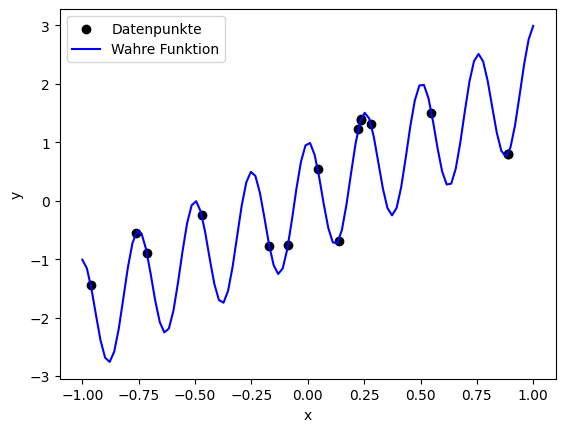

In [342]:
t = np.linspace(-1, 1, 100)
x = np.random.uniform(-1, 1, 15)
yx = 2*x+np.cos(25*x)
yt = 2*t+np.cos(25*t)

plt.Figure(figsize=(8,5))
plt.scatter(x, yx, color='black', label='Datenpunkte')
plt.plot(t, yt, color='blue', label='Wahre Funktion')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Minimum-Norm Lösung (lineares Modell): [0.21150094 1.39920679]


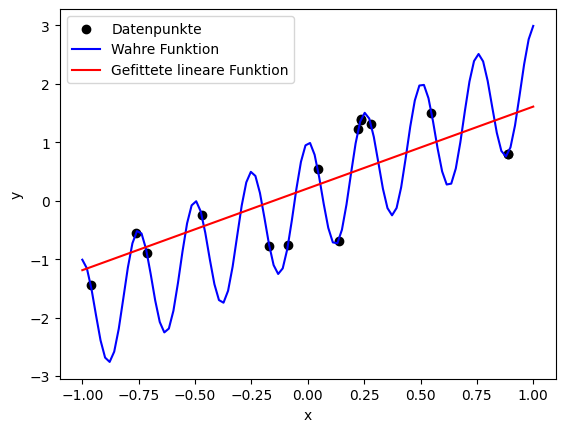

Mean Squared Error (lineares Modell): 0.42252029927987844
Bias (lineares Modell): 5.181040781584064e-17
Varianz (lineares Modell): 0.5754141515114868


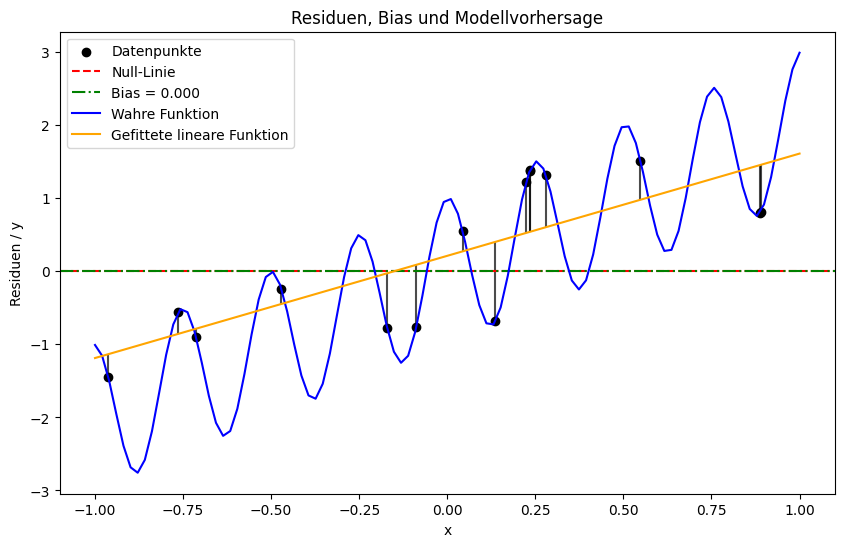

In [343]:
# Wir fangen mit einem linearen model an:

# y = beta_0 + beta_1*x 

# Designmatrix X
X = np.column_stack([np.ones_like(x), x])

# Jetzt verwenden wir SVD um die Minimum-Norm Lösung zu finden
U, S, VT = np.linalg.svd(X)

V = VT.T
Sigma = np.zeros_like(X)
np.fill_diagonal(Sigma, S)
X_pinv = V @ np.linalg.pinv(Sigma) @ U.T
beta_min_norm = X_pinv @ yx
print("Minimum-Norm Lösung (lineares Modell):", beta_min_norm)

# In beta_min_norm haben wir nur 2 Parameter, die die minimale Norm Lösung für das lineare Modell darstellen.

# Jetzt visualisieren wir die Lösung:
t = np.linspace(-1, 1, 100)
yt_fit = beta_min_norm[0] + beta_min_norm[1]*t
plt.Figure(figsize=(8,5))
plt.scatter(x, yx, color='black', label='Datenpunkte')
plt.plot(t, yt, color='blue', label='Wahre Funktion')
plt.plot(t, yt_fit, color='red', label='Gefittete lineare Funktion')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# jetzt berechnen wir die residuen 
residuals = yx - (beta_min_norm[0] + beta_min_norm[1]*x)

# jetzt berechnen wir den MSE (Mean Squared Error)
mse = np.mean(residuals**2)
print("Mean Squared Error (lineares Modell):", mse)

# Jetzt bestimmen wir bias und Varianz des Modells
y_pred = beta_min_norm[0] + beta_min_norm[1]*x
bias = np.mean(y_pred - yx)
variance = np.var(y_pred)
print("Bias (lineares Modell):", bias)
print("Varianz (lineares Modell):", variance)

# Jetzt plotten wir die Residuen 
# Plot
plt.figure(figsize=(10,6))

# Residuen
# Vertikale Residuenlinien
for xi, yi, y_hat_i in zip(x, yx, y_pred):
    plt.vlines(xi, ymin=y_hat_i, ymax=yi, color='black', linestyle='-', alpha=0.7)


plt.scatter(x, yx, color='black', label='Datenpunkte')

# Null-Linie
plt.axhline(0, color='red', linestyle='--', label='Null-Linie')

# Bias-Linie
plt.axhline(bias, color='green', linestyle='-.', label=f'Bias = {bias:.3f}')

# Vorhersagebereich
t = np.linspace(-1, 1, 100)
yt_fit = beta_min_norm[0] + beta_min_norm[1]*t
plt.plot(t, yt, color='blue', label='Wahre Funktion')
plt.plot(t, yt_fit, color='orange', label='Gefittete lineare Funktion')

plt.xlabel('x')
plt.ylabel('Residuen / y')
plt.legend()
plt.title('Residuen, Bias und Modellvorhersage')
plt.show()


In [344]:
import numpy as np
import matplotlib.pyplot as plt

from numpy.polynomial import Legendre
from numpy.polynomial import legendre as lg

def fit_polynomial(x, y, degree=1, true_func=None, plot=True):
    """
    Fit a polynomial of given degree to data (x, y),
    compute bias and variance, and optionally plot residuals.

    Parameters:
    -----------
    x : array-like, shape (n,)
        Input features
    y : array-like, shape (n,)
        True values
    degree : int
        Degree of polynomial
    true_func : callable, optional
        True function y=f(x) for plotting
    plot : bool
        Whether to generate plot

    Returns:
    --------
    beta : array, polynomial coefficients (highest degree first)
    bias : float
    variance : float
    """
    # Designmatrix für Polynomfit
    X = np.vander(x, N=degree+1, increasing=False)  # Vandermonde: highest degree first

    # Minimum-Norm Lösung via SVD
    U, S, VT = np.linalg.svd(X, full_matrices=False)
    V = VT.T
    Sigma_inv = np.diag(1/S)
    X_pinv = V @ Sigma_inv @ U.T
    beta = X_pinv @ y

    # Vorhersage
    y_pred = X @ beta

    # Residuen
    residuals = y - y_pred

    # Bias & Varianz
    bias = np.mean(y_pred - y)
    variance = np.var(y_pred)
    
    # MSE 
    mse = np.mean(residuals**2)

    # Plotten
    if plot:
        plt.figure(figsize=(10,6))
        plt.scatter(x, y, color='black', label='Datenpunkte')

        # Gefittetes Polynom
        t = np.linspace(np.min(x), np.max(x), 200)
        X_t = np.vander(t, N=degree+1, increasing=False)
        y_fit = X_t @ beta
        plt.plot(t, y_fit, color='red', label=f'Gefittetes Polynom (Grad {degree})')

        # Wahre Funktion (optional)
        if true_func is not None:
            plt.plot(t, true_func(t), color='blue', linestyle='--', label='Wahre Funktion')

        # Residuen als vertikale Linien
        for xi, yi, y_hat_i in zip(x, y, y_pred):
            plt.vlines(xi, ymin=y_hat_i, ymax=yi, color='gray', alpha=0.7)

        # Bias-Linie
        plt.axhline(np.mean(y) + bias, color='green', linestyle='-.', label=f'Bias ≈ {bias:.3f}')

        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Polynomfit Grad {degree}, Bias & Varianz')
        plt.legend()
        plt.show()

    return beta, bias, variance, mse


import numpy as np
import matplotlib.pyplot as plt

def test_mse_plot(betas, x_test, y_test, degrees=None, plot=True):
    """
    Berechnet Test-MSE für eine Liste von Polynomialkoeffizienten und plottet optional.

    Parameters
    ----------
    betas : list of arrays
        Jede Array enthält die Polynomkoeffizienten für einen bestimmten Grad
    x_test : array-like
        Test-Features
    y_test : array-like
        Test-Zielwerte
    degrees : list of int, optional
        Polynomialgrade (für Plot)
    plot : bool
        Ob der Plot erzeugt werden soll

    Returns
    -------
    mse_list : list of float
        Test-MSEs für alle Polynomialgrade
    """
    mse_list = []
    for beta in betas:
        X_test = np.vander(x_test, N=len(beta), increasing=False)
        y_pred = X_test @ beta
        mse = np.mean((y_test - y_pred)**2)
        mse_list.append(mse)
    
    if plot:
        if degrees is None:
            degrees = list(range(1, len(betas)+1))
        plt.figure(figsize=(8,5))
        plt.plot(degrees, mse_list, marker='o', color='blue')
        plt.xlabel('Polynomgrad')
        plt.ylabel('Test MSE')
        plt.title('Test MSE vs. Polynomgrad')
        plt.grid(True)
        plt.show()
    
    return mse_list


def legendre_design_matrix(x, degree):
    """
    Erzeugt die Designmatrix für Legendre-Polynome bis Grad 'degree'.
    x sollte im Intervall [-1, 1] liegen.
    """
    n = len(x)
    X = np.zeros((n, degree + 1))
    for i in range(degree + 1):
        coeffs = [0]*i + [1]  # i-th Legendre Polynomial
        X[:, i] = lg.legval(x, coeffs)
    return X

def fit_legendre(x, y, degree=1, true_func=None, plot=True):
    """
    Fit a Legendre polynomial (minimum-norm solution) to data (x, y),
    compute bias, variance, MSE, and optionally plot residuals.
    """
    # Designmatrix
    X = legendre_design_matrix(x, degree)

    # Minimum-Norm Lösung via SVD
    U, S, VT = np.linalg.svd(X, full_matrices=False)
    X_pinv = VT.T @ np.diag(1/S) @ U.T
    beta = X_pinv @ y

    # Vorhersage
    y_pred = X @ beta

    # Bias & Varianz
    bias = np.mean(y_pred - y)
    variance = np.var(y_pred)

    # MSE
    mse = np.mean((y - y_pred)**2)

    # Plotten
    if plot:
        plt.figure(figsize=(10,6))
        plt.scatter(x, y, color='black', label='Datenpunkte')

        t = np.linspace(-1, 1, 200)
        X_t = legendre_design_matrix(t, degree)
        y_fit = X_t @ beta
        plt.plot(t, y_fit, color='red', label=f'Legendre Fit Grad {degree}')

        if true_func is not None:
            plt.plot(t, true_func(t), color='blue', linestyle='--', label='Wahre Funktion')

        # Residuen als vertikale Linien
        for xi, yi, y_hat_i in zip(x, y, y_pred):
            plt.vlines(xi, ymin=y_hat_i, ymax=yi, color='gray', alpha=0.7)

        # Bias-Linie
        plt.axhline(np.mean(y) + bias, color='green', linestyle='-.', label=f'Bias ≈ {bias:.3f}')

        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'Legendre Polynomfit Grad {degree}, Bias & Varianz')
        plt.legend()
        plt.show()

    return beta, bias, variance, mse

def test_mse_legendre(betas, x_test, y_test, degrees=None, plot=True):
    """
    Berechnet Test-MSE für eine Liste von Legendre-Koeffizienten (Minimum-Norm Lösung).
    """
    mse_list = []
    for beta in betas:
        X_test = legendre_design_matrix(x_test, len(beta)-1)
        y_pred = X_test @ beta
        mse = np.mean((y_test - y_pred)**2)
        mse_list.append(mse)

    if plot:
        if degrees is None:
            degrees = list(range(1, len(betas)+1))
        plt.figure(figsize=(8,5))
        plt.plot(degrees, mse_list, marker='o', color='blue', label='Test MSE')
        plt.xlabel('Polynomgrad')
        plt.ylabel('Test MSE')
        plt.title('Test MSE vs. Polynomgrad (Legendre Basis, Minimum-Norm)')
        plt.yscale('log')
        plt.grid(True)
        plt.legend()
        plt.show()

    return mse_list



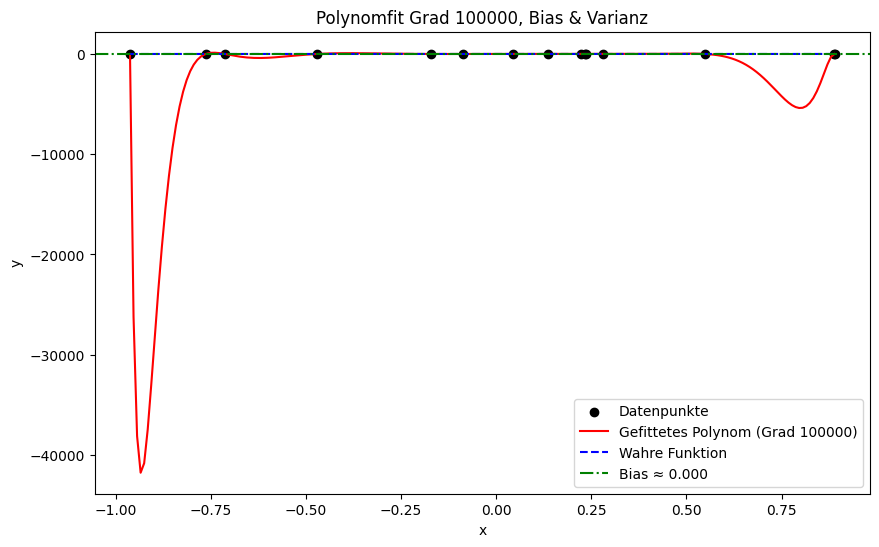

Bias: 4.074744960706293e-08
Varianz: 0.9979344377690558
MSE: 7.225887489746851e-15


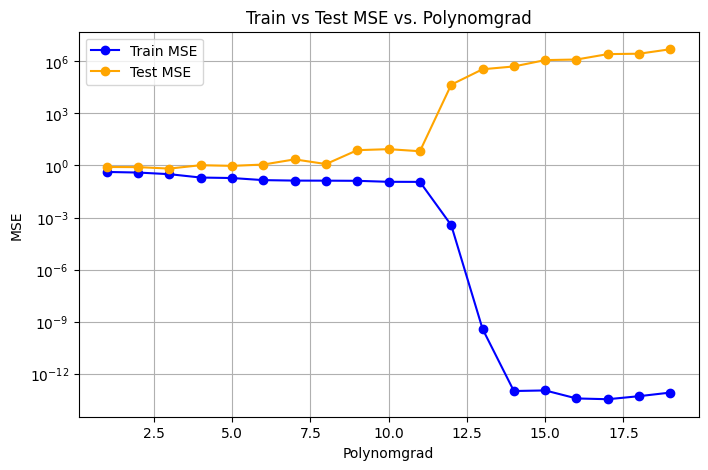

In [345]:
beta, bias, variance, mse = fit_polynomial(x, yx, degree=100000, true_func=lambda t: 2*t+np.cos(25*t))


#print("Beta:", beta)
print("Bias:", bias)
print("Varianz:", variance)
print("MSE:", mse)

# generiere Testdaten
np.random.seed(42)
x_test = np.random.uniform(-1, 1, 20)
y_test = 2*x_test + np.cos(25*x_test) + np.random.normal(0, 0.1, size=x_test.shape)

betas = []
train_mse = []
pol_grads = []
for deg in range(1, int(20)):
    deg = deg
    beta, bias, variance, mse = fit_polynomial(x, yx, degree=deg, true_func=lambda t: 2*t+np.cos(25*t),plot=False)
    betas.append(beta)
    train_mse.append(mse)
    pol_grads.append(deg)

# Test-MSE plotten
mse_list = test_mse_plot(betas, x_test, y_test, plot=False)

# Plot Train vs Test MSE over Degree

plt.figure(figsize=(8,5))
plt.plot(pol_grads, train_mse, marker='o', label='Train MSE', color='blue')
plt.plot(pol_grads, mse_list, marker='o', label='Test MSE', color='orange')
plt.xlabel('Polynomgrad')
# log scale for better visibility
plt.yscale('log')
plt.ylabel('MSE')
plt.title('Train vs Test MSE vs. Polynomgrad')
plt.legend()
plt.grid(True)
plt.show()

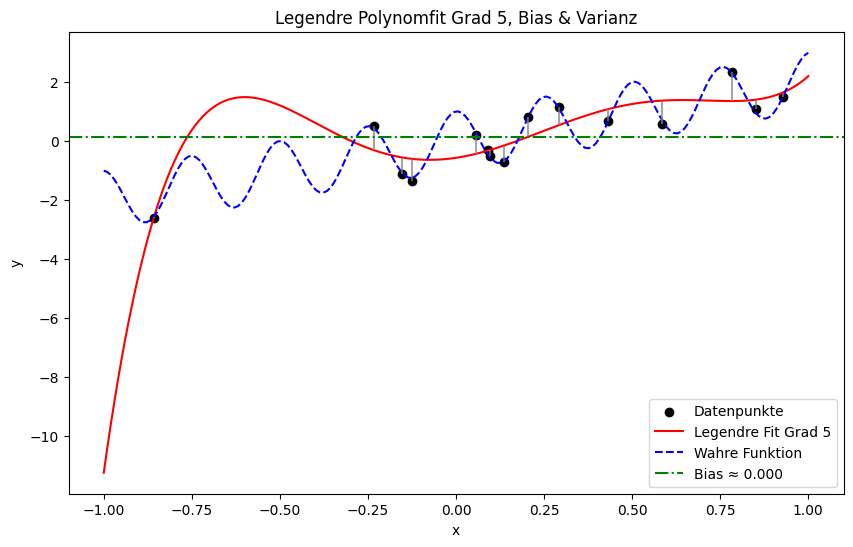

Bias: 0.0
Varianz: 1.161113240755182
MSE: 0.3297136216979123


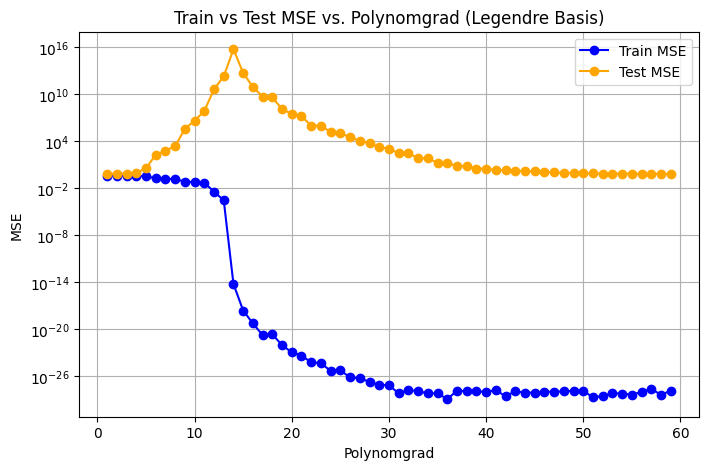

: 

In [ ]:
# Trainingsdaten
np.random.seed(0)
x = np.random.uniform(-1, 1, 15)
yx = 2*x + np.cos(25*x) + np.random.normal(0, 0.1, size=x.shape)

# Beispiel: sehr hoher Grad fitten (stabil mit Legendre)
beta, bias, variance, mse = fit_legendre(x, yx, degree=5, true_func=lambda t: 2*t+np.cos(25*t))

print("Bias:", bias)
print("Varianz:", variance)
print("MSE:", mse)

# Testdaten
np.random.seed(42)
x_test = np.random.uniform(-1, 1, 200)
y_test = 2*x_test + np.cos(25*x_test) + np.random.normal(0, 0.1, size=x_test.shape)

# Train-MSE für mehrere Polynomialgrade
betas = []
train_mse = []
pol_grads = list(range(1, 60))
for deg in pol_grads:
    beta, bias, variance, mse = fit_legendre(x, yx, degree=deg, true_func=lambda t: 2*t+np.cos(25*t), plot=False)
    betas.append(beta)
    train_mse.append(mse)

# Test-MSE berechnen
mse_list = test_mse_legendre(betas, x_test, y_test, degrees=pol_grads, plot=False)

# Plot Train vs Test MSE
plt.figure(figsize=(8,5))
plt.plot(pol_grads, train_mse, marker='o', label='Train MSE', color='blue')
plt.plot(pol_grads, mse_list, marker='o', label='Test MSE', color='orange')
plt.xlabel('Polynomgrad')
plt.ylabel('MSE')
plt.title('Train vs Test MSE vs. Polynomgrad (Legendre Basis)')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.show()